In [1]:
 # Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing    import StandardScaler
from sklearn.model_selection  import train_test_split
from sklearn.datasets         import fetch_openml
from sklearn.metrics          import classification_report, confusion_matrix
from sklearn.metrics          import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn                 import datasets
from sklearn.svm import SVC



In [20]:
# Plot a re-usable functions


def plot_auc_cm(y_true, y_pred_proba, y_pred):

    # AUC
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    auc_score = roc_auc_score(y_true, y_pred_proba)

    # Plot AUC
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
    plt.plot([0,1],[0,1],'--', color='grey')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title('ROC Curve'); plt.legend()

    # Confusion Matrix
    plt.subplot(1,2,2)
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm).plot(ax=plt.gca(), cmap='Blues', colorbar=False)
    plt.title('Confusion Matrix')

    plt.tight_layout(); plt.show()

    # Classification Report
    print(classification_report(y_true, y_pred))



**Linear SVM Classification**


In [12]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score


In [5]:
# Load dataset
diabetes = load_diabetes()
X = diabetes.data  # features
y = diabetes.target  # target

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Scale features (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**Train Linear SVM**

In [13]:


svr_linear = SVR(kernel='linear', C=1.0, epsilon=0.1)
svr_linear.fit(X_train_scaled, y_train)

# Predict
y_pred = svr_linear.predict(X_test_scaled)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R^2 Score:", r2)


Mean Squared Error: 2939.8127804183164
R^2 Score: 0.44512484353785875


**Nonlinear SVM Classification (Wine Quality Dataset)**

For nonlinear SVM classification, we will use the Wine Quality dataset from the UCI Machine Learning Repository. It contains 11 features related to the chemical properties of wines and their quality ratings.

In [14]:
# Load Wine Quality dataset from OpenML
wine = fetch_openml(name='wine-quality-red',parser='auto')
X = wine.data
y = wine.target

In [15]:
# Convert target to binary classification problem: Good (quality > 5) or Bad (quality <= 5)
y = (y.astype(int) > 5).astype(int)

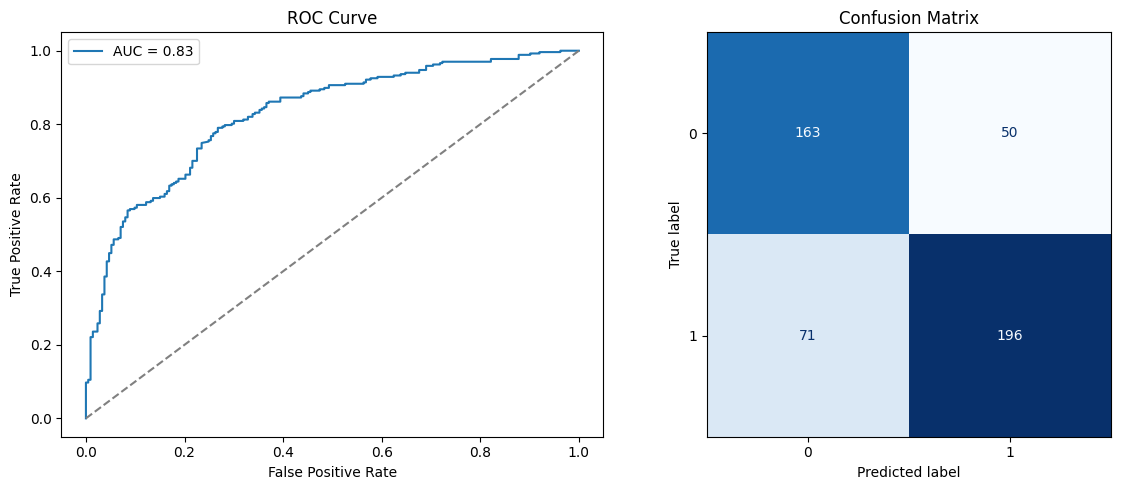

              precision    recall  f1-score   support

           0       0.70      0.77      0.73       213
           1       0.80      0.73      0.76       267

    accuracy                           0.75       480
   macro avg       0.75      0.75      0.75       480
weighted avg       0.75      0.75      0.75       480



In [22]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Train Nonlinear SVM with RBF kernel
clf_rbf = SVC(kernel='rbf', gamma='scale',probability=True)
clf_rbf.fit(X_train, y_train)

y_pred_proba_rbf = clf_rbf.predict_proba(X_test)[:, 1]
y_pred_rbf       = clf_rbf.predict(X_test)

# Plot AUC, Confusion Matrix, and Classification Report
plot_auc_cm(y_test, y_pred_proba_rbf, y_pred_rbf)

 Polynomial Kernel (Wine Quality Dataset)

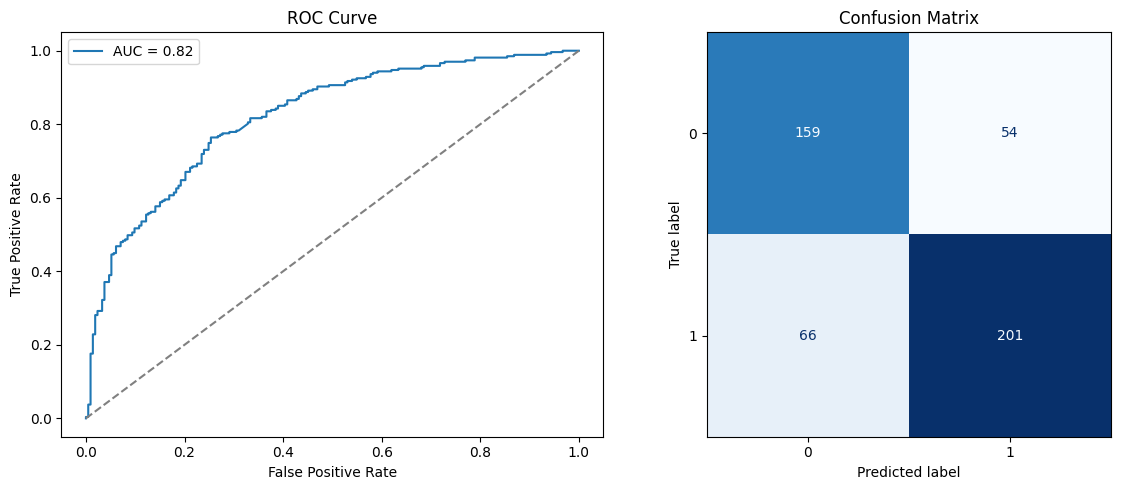

              precision    recall  f1-score   support

           0       0.71      0.75      0.73       213
           1       0.79      0.75      0.77       267

    accuracy                           0.75       480
   macro avg       0.75      0.75      0.75       480
weighted avg       0.75      0.75      0.75       480



In [21]:
# Train SVM with Polynomial Kernel

clf_poly = SVC(kernel='poly', degree=3, gamma='scale',probability=True)
clf_poly.fit(X_train, y_train)

y_pred_proba_poly = clf_poly.predict_proba(X_test)[:, 1]
y_pred_poly = clf_poly.predict(X_test)

# Plot AUC, Confusion Matrix, and Classification Report
plot_auc_cm(y_test, y_pred_proba_poly, y_pred_poly)
